In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import matplotlib.lines as mlines
import h5py
from pathlib import Path


=== TABLE (d errors) ===

    M [Msun]      SNR            d    σ_d/d [%]          d95
-----------------------------------------------------------------
    1.00e+06     90.7   1.0000e-02       177.03   0.0000e+00
    1.00e+06     90.7   1.5000e-02        73.73   0.0000e+00
    1.00e+06     90.7   2.0000e-02        41.54   0.0000e+00
    1.00e+06     90.7   2.5000e-02        26.61   0.0000e+00
    1.00e+06     90.7   5.0000e-02         6.79   0.0000e+00
    5.00e+05     75.7   7.0000e-03       141.89   0.0000e+00
    5.00e+05     75.7   1.0000e-02        25.19   0.0000e+00
    5.00e+05     75.7   1.5000e-02        10.59   0.0000e+00
    5.00e+05     75.7   2.0000e-02         6.40   0.0000e+00
    5.00e+05     75.7   2.5000e-02         4.31   0.0000e+00
    5.00e+05     75.7   5.0000e-02         1.08   0.0000e+00
    1.00e+06     90.7   0.0000e+00         0.00   2.3316e-02
    5.00e+05     75.7   0.0000e+00         0.00   9.2560e-03

=== MACROS ===

\newcommand{\MOneESixDOneEMinusTwoRe

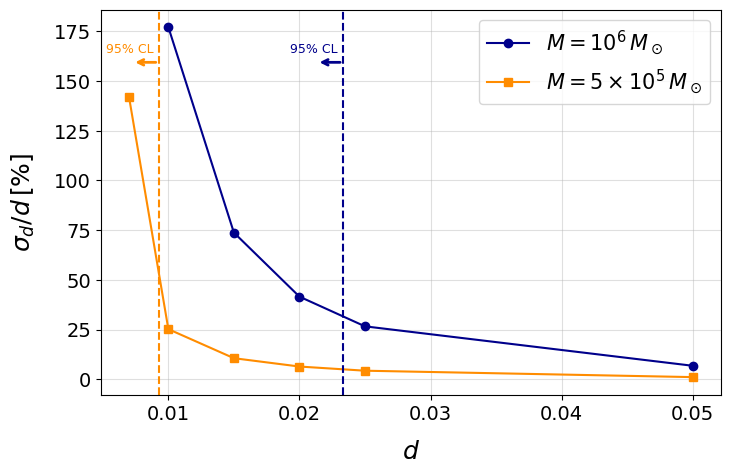

In [28]:
import numpy as np
import h5py
from pathlib import Path
import matplotlib.pyplot as plt

# -------------------------
# Importing files
# -------------------------
BASE_DIR = Path.cwd()  # notebook directory
file_path = BASE_DIR / "scalar_results" / "results_FoM" / "massless" / "realization_0"

# -------------------------
# Filese with Lambda=d^2 >0
# -------------------------
file_names = [
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.9999999999760818_Lambda0.0001_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.9999999999760958_Lambda0.000225_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.9999999999761147_Lambda0.0004_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.9999999999761429_Lambda0.000625_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.9999999999763676_Lambda0.0025_ScalarMass0.0_z0.2_der_order4.0.h5",
    
    "results_M5e+05_mu10.0_a0.9_ef0.0_T1.9999999999999998_Lambda4.9e-05_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M5e+05_mu10.0_a0.9_ef0.0_T1.9999999999999998_Lambda0.0001_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M5e+05_mu10.0_a0.9_ef0.0_T1.9999999999999998_Lambda0.000225_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M5e+05_mu10.0_a0.9_ef0.0_T1.9999999999999998_Lambda0.0004_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M5e+05_mu10.0_a0.9_ef0.0_T1.9999999999999998_Lambda0.000625_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M5e+05_mu10.0_a0.9_ef0.0_T1.9999999999999998_Lambda0.0025_ScalarMass0.0_z0.2_der_order4.0.h5",
]

# ----------------------------------------
# Files with Lambda=d^2 = 0 (upper bounds)
# ----------------------------------------
upper_bound_files = [
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.9999999999760698_Lambda0.0_ScalarMass0.0_z0.2_der_order4.0.h5",
    "results_M5e+05_mu10.0_a0.9_ef0.0_T1.9999999999999998_Lambda0.0_ScalarMass0.0_z0.2_der_order4.0.h5"
]

idx_lambda = -1 
number_M1e6 = 5

d_values_1M, rel_err_1M = [], []
d_values_5e5, rel_err_5e5 = [], []

table_rows = []

def lambda_to_d_fisher(fisher, d_value, idx_lambda):
    fisher_new = fisher.copy()
    factor = 2.0 * d_value
    fisher_new[idx_lambda, :] *= factor
    fisher_new[:, idx_lambda] *= factor
    return fisher_new

for i, fn in enumerate(file_names):
    path = file_path / fn
    with h5py.File(path, "r") as f:
        fisher = f["gamma"][()]
        params = f["fisher_params"][()]
        snr_old = f["snr"][()]
        sigma_lambda = f["errors"][-1][()]

    M_val = params[0]
    Lambda_val = params[idx_lambda]
    d_val = np.sqrt(Lambda_val)

    # Fisher -> d
    #fisher_d = lambda_to_d_fisher(fisher, d_val, idx_lambda)
    #cov_d = np.linalg.inv(fisher_d)
    #cov_1d = cov_d[np.ix_([idx_lambda],[idx_lambda])]
    #sigma_d = np.sqrt(np.diag(cov_1d))[0]
    sigma_d = sigma_lambda / (2*d_val)
    rel_pct = sigma_d / d_val * 100.0

    # groups with M 
    if i < number_M1e6:
        d_values_1M.append(d_val)
        rel_err_1M.append(rel_pct)
    else:
        d_values_5e5.append(d_val)
        rel_err_5e5.append(rel_pct)

    table_rows.append({
        "M": float(M_val),
        "snr": float(snr_old),
        "d": float(d_val),
        "rel_err_d": float(rel_pct),
        "d95": np.nan
    })

# -------------------------
# Loop upper bound Lambda=0
# -------------------------
for ub_file in upper_bound_files:
    path = file_path / ub_file
    ext = path.suffix
    
    with h5py.File(path, "r") as f:
        params = f["fisher_params"][()]
        sigma_lambda = f["errors"][-1][()]
        snr_old = f["snr"][()]

    d95 = np.sqrt(1.64 * sigma_lambda)  # upper bound 95% 
    M_val = params[0]

    table_rows.append({
        "M": M_val,
        "snr": float(snr_old),
        "d": 0.0,
        "rel_err_d": np.nan,
        "d95": d95
    })

# -------------------------
# Printing table
# -------------------------

print("\n=== TABLE (d errors) ===\n")

print(f"{'M [Msun]':>12} {'SNR':>8} {'d':>12} {'σ_d/d [%]':>12} {'d95':>12}")
print("-"*65)
for row in table_rows:
    print(
        f"{row['M']:12.2e} "
        f"{(row['snr'] if not np.isnan(row['snr']) else 0):8.1f} "
        f"{row['d']:12.4e} "
        f"{(row['rel_err_d'] if not np.isnan(row['rel_err_d']) else 0):12.2f} "
        f"{(row['d95'] if not np.isnan(row['d95']) else 0):12.4e}"
    )

# -------------------------
#  MACROS for LaTeX
# -------------------------

print("\n=== MACROS ===\n")

num_map = {
    "0": "Zero", "1": "One", "2": "Two", "3": "Three", "4": "Four",
    "5": "Five", "6": "Six", "7": "Seven", "8": "Eight", "9": "Nine"
}

def format_M_label(M):
    """Converte M numerico in macro tipo OneESix o FiveEFive"""
    if M == 1e6:
        return "OneESix"
    elif M == 5e5:
        return "FiveEFive"
    else:
        # fallback generico
        exp = int(np.floor(np.log10(M)))
        base = M / 10**exp
        base_str = str(int(base)) if base.is_integer() else f"{base:.1f}".replace(".", "")
        return f"{base_str}E{exp}"

def format_d_label(d):
    if d == 0.0:
        return "Zero"

    exp = int(np.floor(np.log10(d)))
    base = d / 10**exp

    a, b = f"{base:.1f}".split(".")
    label = num_map[a]
    if b != "0":
        label += num_map[b]
    exp_abs = abs(exp)
    exp_str = "".join(num_map[d] for d in str(exp_abs))

    sign = "Minus" if exp < 0 else ""

    return f"{label}E{sign}{exp_str}"

def make_macro_name(row):
    M_label = format_M_label(row["M"])
    if row["d"] == 0.0 and not np.isnan(row["d95"]):
        # upper bound
        return f"\\M{M_label}DZeroUpperBound"
    else:
        d_label = format_d_label(row["d"])
        return f"\\M{M_label}D{d_label}RelErr"

def generate_macros(table_rows):
    lines = []
    for row in table_rows:
        macro = make_macro_name(row)
        if not np.isnan(row['rel_err_d']):
            val = row['rel_err_d']
            # arrotondamento dinamico
            if val >= 1.0:
                val_str = f"{val:.0f}"   # numero intero
            else:
                val_str = f"{val:.1f}"   # una cifra decimale
            lines.append(f"\\newcommand{{{macro}}}{{\\ensuremath{{{val_str}}}\\%}}")
        elif not np.isnan(row['d95']):
            def sci_notation_latex(x):
                exp = int(np.floor(np.log10(x)))
                base = x / 10**exp
                return f"{base:.1f} \\times 10^{{{exp}}}"

            val = row['d95']
            val_str = sci_notation_latex(val)
            lines.append(f"\\newcommand{{{macro}}}{{\\ensuremath{{{val_str}}}}}")

                
    return "\n".join(lines)

macros = generate_macros(table_rows)
print(macros)

# -----------------------------------
# Plot σ_d/d [%] vs d and upper bounds
# -----------------------------------

plt.figure(figsize=(8,5))
plt.plot(d_values_1M, rel_err_1M, "o-", color = "darkblue", label=r"$M = 10^6\,M_\odot$")
plt.plot(d_values_5e5, rel_err_5e5, "s-", color = "darkorange", label=r"$M = 5\times10^5\,M_\odot$")

# linee verticali per upper bounds
for row in table_rows:
    if row["d"] == 0.0 and not np.isnan(row["d95"]):
        # color
        color = "darkblue" if row["M"] == 1e6 else "darkorange"
        plt.axvline(row["d95"], linestyle="--", color=color)

        # arrow
        y_max = max(rel_err_1M) 
        dx = 0.002 # arrow length
        plt.annotate(
            '',
            xy=(row["d95"], y_max*0.9),       
            xytext=(row["d95"]-dx, y_max*0.9),
            arrowprops=dict(arrowstyle='<-', color=color, lw=2)
        )

        #plt.axvspan(0, row["d95"], alpha=0.15, color=color) #shadow, removed
        
        #text above the arrow
        plt.text(
                row["d95"]-dx/0.9,    
                y_max*0.92,         
                "95% CL",
                color=color,
                fontsize=9,
                ha='center',          
                va='bottom'          
            ) 


plt.xlabel(r"$d$", fontsize=18,labelpad = 12)
plt.ylabel(r"$\sigma_d / d \,[\%]$", fontsize=18, labelpad = 12)
plt.tick_params(axis='both', labelsize=14)
plt.grid(alpha=0.4)
plt.legend(fontsize=15)
plt.savefig("figures/errors_charge.pdf", bbox_inches="tight")